# Flow Matching: Concepts and Theory

This notebook demonstrates **flow matching**, a technique for generative modeling using neural ordinary differential equations (ODEs).

## Key Concepts

- **Generative Modeling**: The goal is to learn a mapping from a simple distribution (e.g., Gaussian noise) to a complex data distribution (e.g., moons dataset).
- **Flow-based Models**: These models transform samples from a base distribution into samples from the target distribution using invertible mappings.
- **Neural ODEs**: Instead of discrete transformations, neural ODEs model the transformation as a continuous-time flow, parameterized by a neural network.
- **Flow Matching**: The model learns to match the velocity field (the derivative of the data with respect to time) along straight lines interpolating between noise and data. The neural network predicts the displacement needed to move a sample from the base distribution towards the data distribution at each time step.

## Implementation Overview

1. **Data Preparation**: The code uses the `make_moons` dataset as the target distribution and standard Gaussian noise as the base distribution.
2. **Model**: A neural network takes as input a point and a time value, and predicts the velocity (displacement) needed to move the point towards the data distribution.
3. **Training**: The model is trained to minimize the mean squared error between its predicted displacement and the true displacement between noise and data samples.
4. **Sampling**: After training, new samples are generated by starting from Gaussian noise and integrating the learned velocity field over time using Euler's method.
5. **Plotting**: The samples at each integration step are visualized to show the transformation from noise to the data distribution.

This approach is related to score-based generative modeling and diffusion models, but uses a direct matching of flows instead of learning the score (gradient of log-density).

## 1. Data Preparation
Prepare the target (moons) and base (Gaussian) distributions.

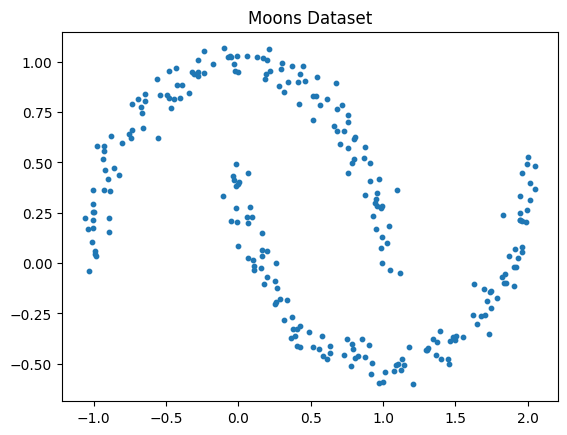

In [1]:
# Import necessary libraries
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Example: visualize the moons dataset
X_moons, _ = make_moons(256, noise=0.05)
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=10)
plt.title('Moons Dataset')
plt.show()

## 2. Model Definition
Define the neural ODE-based flow matching model.

In [2]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        # Define a simple MLP that takes (x_t, t) as input and outputs dx_t
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))

    def forward(self, x_t: Tensor, t: Tensor) -> Tensor:
        # Concatenate x_t and t along the last dimension and pass through the network
        return self.net(torch.cat((x_t, t), -1))

    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        # Expand t_start and t_end to match batch size
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        t_end = t_end.view(1, 1).expand(x_t.shape[0], 1)
        dt = t_end - t_start  # Time step size
        dx = self.forward(x_t, t_start)  # Predict dx/dt at t_start
        return x_t + dx * dt  # Euler integration step

## 3. Training
Train the model to match the flow between the base and target distributions.

In [3]:
# Instantiate the flow model, optimizer, and loss function
flow = Flow()
optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

# Training loop
for _ in range(10000):
    x_1 = Tensor(make_moons(256, noise=0.05)[0])  # Sample data from moons distribution
    x_0 = torch.randn_like(x_1)  # Sample from standard normal
    t = torch.rand(len(x_1), 1)  # Uniformly sample time between 0 and 1
    x_t = (1- t) * x_0 + t * x_1  # Interpolate between x_0 and x_1
    dx_t = x_1 - x_0  # True displacement
    optimizer.zero_grad()
    loss = loss_fn(flow(x_t, t), dx_t)  # Compute loss
    loss.backward()
    optimizer.step()

## 4. Sampling
Generate new samples by integrating the learned flow from noise to data.

In [4]:
# Generate samples by integrating the flow
x = torch.randn(300, 2)  # Start from standard normal samples
n_steps = 8  # Number of integration steps
time_steps = torch.linspace(0, 1.0, n_steps + 1)  # Discretize time interval
samples = [x.detach().clone()]  # Store samples at each step
for i in range(n_steps):
    x = flow.step(x, time_steps[i], time_steps[i + 1])  # Integrate forward in time
    samples.append(x.detach().clone())

## 5. Plotting
Visualize the samples at each integration step.

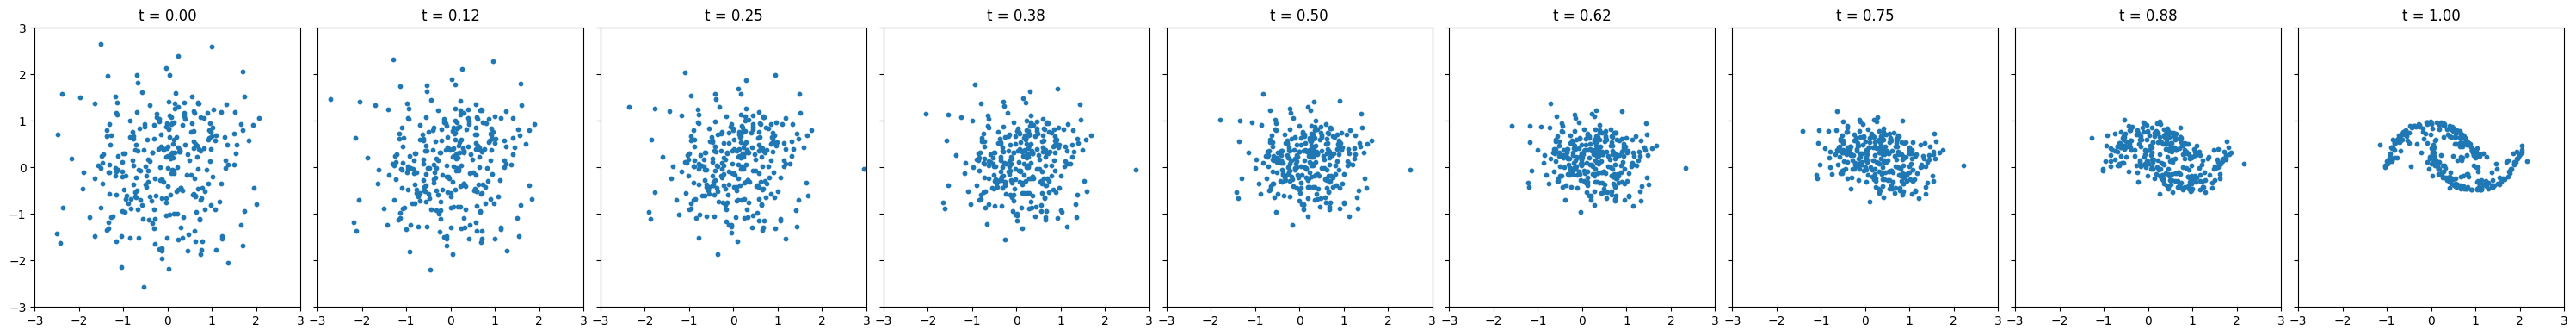

In [5]:
fig, axes = plt.subplots(1, len(samples), figsize=(30, 4), sharex=True, sharey=True)
for i, x_i in enumerate(samples):
    axes[i].scatter(x_i[:, 0], x_i[:, 1], s=10)
    axes[i].set_title(f't = {time_steps[i]:.2f}')
    axes[i].set_xlim(-3.0, 3.0)
    axes[i].set_ylim(-3.0, 3.0)
plt.tight_layout()
plt.show()